In [1]:
# Para atualizar um pacote, execute o comando abaixo no terminal ou prompt de comando:
# pip install -U nome_pacote

# Para instalar a versão exata de um pacote, execute o comando abaixo no terminal ou prompt de comando:
# !pip install nome_pacote==versão_desejada

# Depois de instalar ou atualizar o pacote, reinicie o jupyter notebook.

# Instala o pacote watermark.
# Esse pacote é usado para gravar as versões de outros pacotes usados neste jupyter notebook.
!pip install -q -U watermark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.3 MB/s eta 0:00:00


In [2]:
!pip install -q google-cloud-bigquery

In [3]:
!pip install -q db-dtypes

In [4]:
# Imports
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from google.cloud import bigquery
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "Eduardo Lyrio"

Author: Eduardo Lyrio



# Conectando o Ambiente Python ao Google BigQuery

In [6]:
# Define o caminho do arquivo de credenciais (crie seu arquivo conforme mostrado nas aulas)
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "capitulo08dsa-489811-6c9ead5774ee.json"

In [7]:
# Instancia o cliente do BigQuery
client = bigquery.Client()

In [8]:
# Verifica se a autenticação foi feita corretamente (se a célula anterior foi executada com sucesso)
print("Conectado ao BigQuery")

Conectado ao BigQuery


# Executando Query SQL no Google BigQuery a Partir de Código Python
Consulta para trazer as vendas de um determinado produto.

In [9]:
# Consulta SQL
query = """
    SELECT
        p.Nome AS Nome_Produto,
        f.Valor,
        f.Quantidade,
        c.Nome AS Nome_Canal
    FROM `capitulo08dsa-489811.projeto2.fato_venda` f
    JOIN `capitulo08dsa-489811.projeto2.dim_produto` p ON f.Produto_ID = p.Produto_ID
    JOIN `capitulo08dsa-489811.projeto2.dim_canal` c ON f.Canal_ID = c.Canal_ID
    WHERE p.Nome = 'Produto A'
    LIMIT 100
"""

In [10]:
# Executa a consulta e armazena os resultados em um DataFrame
df_dsa = client.query(query).to_dataframe()

In [11]:
type(df_dsa)



pandas.core.frame.DataFrame

In [12]:
# Exibe os primeiros resultados
df_dsa.head()

,Nome_Produto,Valor,Quantidade,Nome_Canal
0,Produto A,268.22,4,Quiosque
1,Produto A,883.81,12,Loja Online


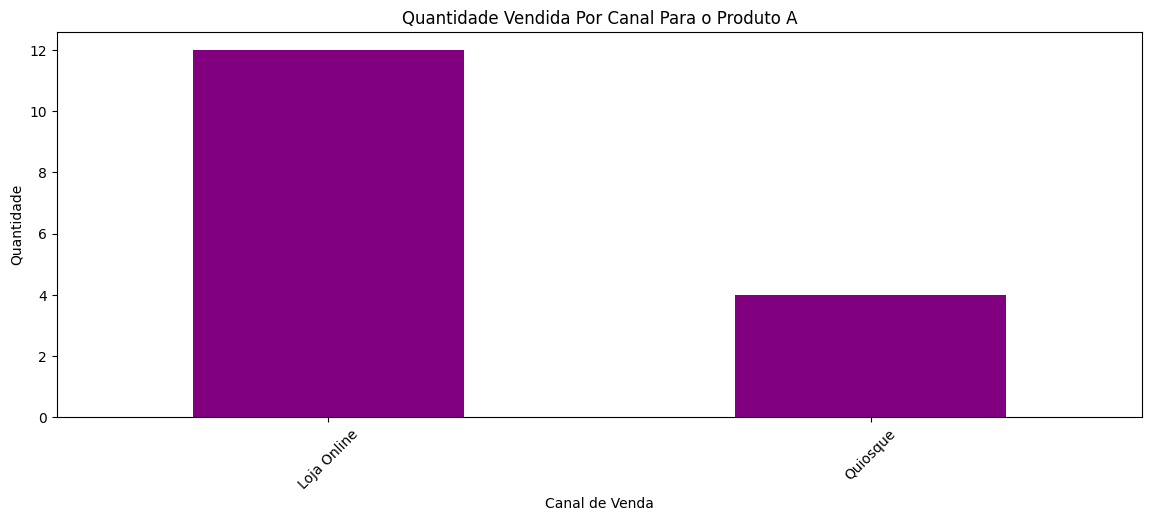

In [13]:
# Plot da quantidade vendida por canal

# Define o tamanho da figura
plt.figure(figsize = (14, 5))

# Agrupa os dados e cria o plot
df_dsa.groupby("Nome_Canal")["Quantidade"].sum().plot(kind = 'bar', color = 'purple')
plt.title('Quantidade Vendida Por Canal Para o Produto A')
plt.ylabel('Quantidade')
plt.xlabel('Canal de Venda')
plt.xticks(rotation = 45)
plt.show()

# Análise de Dados, Gráficos e Relatórios com SQL, Python e Google BigQuery

## Análise dos Principais Clientes Por Vendas Anuais¶
Consulta para encontrar o cliente que mais comprou em valor em cada ano.

In [14]:
# Define a query SQL
query = """
    WITH Total_Cliente_Vendas AS (
        SELECT
            cl.Nome AS Nome_Cliente,
            d.Ano,
            SUM(f.Valor) AS Total_Valor_Vendas,
            ROW_NUMBER() OVER (PARTITION BY d.Ano ORDER BY SUM(f.Valor) DESC) AS Rank_Vendas
        FROM `capitulo08dsa-489811.projeto2.fato_venda` f
        JOIN `capitulo08dsa-489811.projeto2.dim_cliente` cl ON f.Cliente_ID = cl.Cliente_ID
        JOIN `capitulo08dsa-489811.projeto2.dim_data` d ON f.Data_ID = d.Data_ID
        GROUP BY cl.Nome, d.Ano
    )
    SELECT Nome_Cliente, Ano, Total_Valor_Vendas
    FROM Total_Cliente_Vendas
    WHERE Rank_Vendas = 1;
"""

In [15]:
# Executa a consulta no BigQuery
df_dsa = client.query(query).to_dataframe()

In [16]:
# Shape
df_dsa.shape

(6, 3)

In [17]:
# Primeiras linhas
df_dsa.head()

,Nome_Cliente,Ano,Total_Valor_Vendas
0,João Silva,2020,268.22
1,João Silva,2021,2372.14
2,Maria Oliveira,2022,1410.43
3,Fernanda Costa,2023,1307.48
4,Fernanda Costa,2024,2323.62


# Análise de Vendas Por Produto, Canal e Tempo
Aqui você pode analisar as vendas por produto, por canal e por período de tempo, para entender melhor o desempenho de produtos e canais. Além disso, a análise de vendas agregada pode identificar tendências ao longo do tempo.

In [20]:
# Define a query SQL
query = """
SELECT p.Nome AS Produto, d.Mes, d.Ano, SUM(f.Valor) AS Total_Vendas
FROM `capitulo08dsa-489811.projeto2.fato_venda` f
JOIN `capitulo08dsa-489811.projeto2.dim_produto` p ON f.Produto_ID = p.Produto_ID
JOIN `capitulo08dsa-489811.projeto2.dim_data` d ON f.Data_ID = d.Data_ID
GROUP BY p.Nome, d.Mes, d.Ano
ORDER BY d.Ano, d.Mes
"""

In [21]:
# Executa a consulta no BigQuery
df_vendas_produto = client.query(query).to_dataframe()

In [22]:
# Cria uma coluna 'Data' combinando Ano e Mes como string e adicionando '01' como dia
df_vendas_produto['Data'] = pd.to_datetime(df_vendas_produto['Ano'].astype(str) + '-' + df_vendas_produto['Mes'].astype(str) + '-01')

In [23]:
# Verifica se a coluna 'Data' foi criada corretamente
df_vendas_produto.head()

,Produto,Mes,Ano,Total_Vendas,Data
0,Produto A,4,2020,268.22,2020-04-01
1,Produto F,7,2020,216.98,2020-07-01
2,Produto C,1,2021,737.86,2021-01-01
3,Produto H,2,2021,839.33,2021-02-01
4,Produto D,5,2021,1382.35,2021-05-01


In [24]:
# Seleciona os 5 produtos com maior total de vendas
top_n = 5
top_produtos = df_vendas_produto.groupby('Produto')['Total_Vendas'].sum().nlargest(top_n).index
df_filtered = df_vendas_produto[df_vendas_produto['Produto'].isin(top_produtos)]

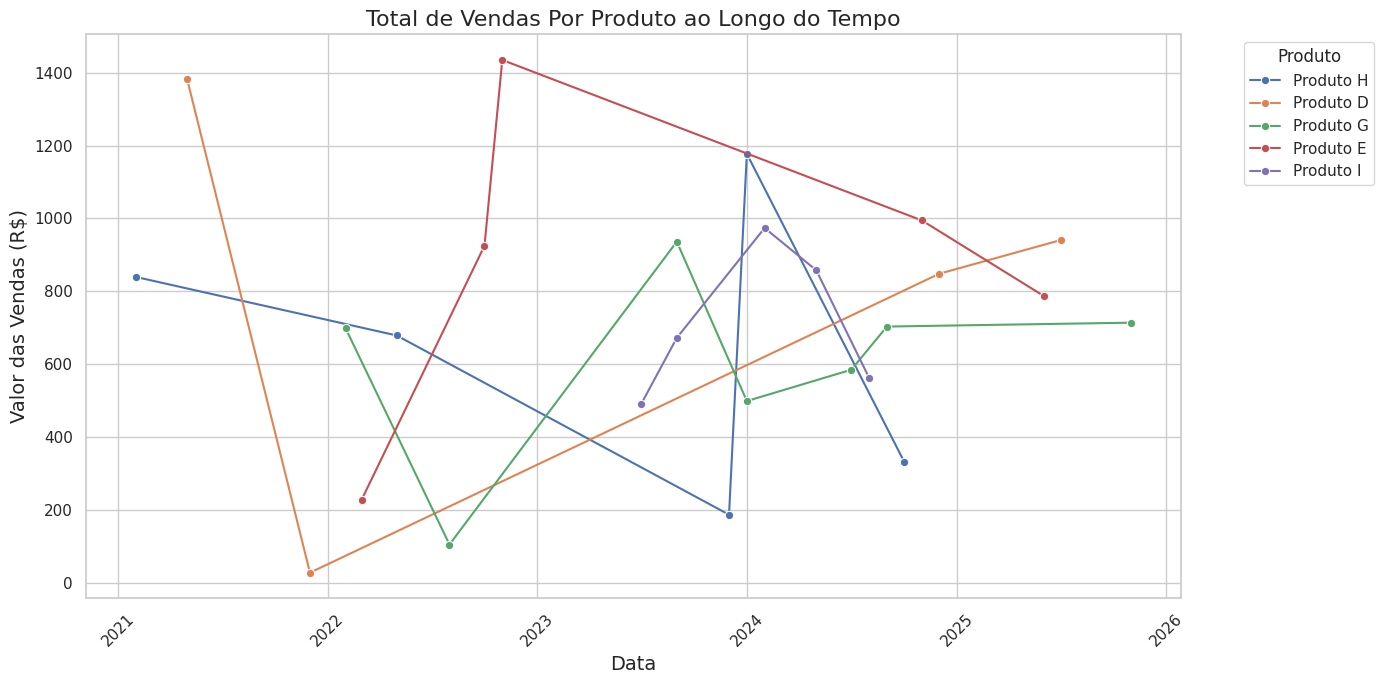

In [25]:
# Plot com seaborn
sns.set(style = "whitegrid")
plt.figure(figsize = (14, 7))
sns.lineplot(data = df_filtered, x = 'Data', y = 'Total_Vendas', hue = 'Produto', marker = 'o')
plt.title('Total de Vendas Por Produto ao Longo do Tempo', fontsize = 16)
plt.xlabel('Data', fontsize = 14)
plt.ylabel('Valor das Vendas (R$)', fontsize = 14)
plt.legend(title ='Produto', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [26]:
# Plot com Plotly (interativo)
fig = px.line(df_filtered,
              x = 'Data',
              y = 'Total_Vendas',
              color = 'Produto',
              title = 'Total de Vendas por Produto ao Longo do Tempo',
              labels = {'Total_Vendas': 'Valor das Vendas (R$)', 'Data': 'Data'})

fig.update_layout(xaxis_title = 'Data',
                  yaxis_title = 'Valor das Vendas (R$)',
                  legend_title = 'Produto',
                  xaxis = dict(tickformat = '%Y-%m', tickangle = 45))

fig.show()

<Figure size 1400x700 with 0 Axes>

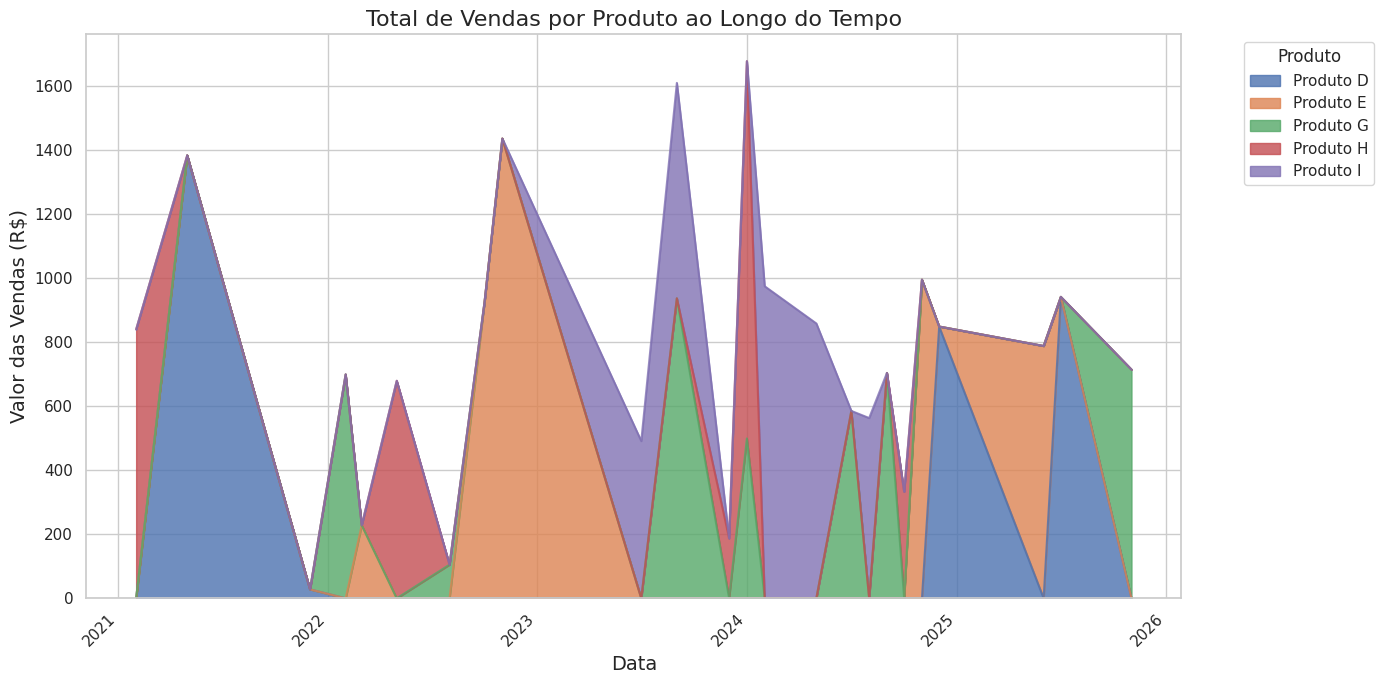

In [27]:
# Gráfico de Área Empilhada
df_pivot = df_filtered.pivot(index = 'Data', columns = 'Produto', values = 'Total_Vendas').fillna(0)
plt.figure(figsize = (14, 7))
df_pivot.plot(kind = 'area', stacked = True, figsize = (14, 7), alpha = 0.8)
plt.title('Total de Vendas por Produto ao Longo do Tempo', fontsize=16)
plt.xlabel('Data', fontsize = 14)
plt.ylabel('Valor das Vendas (R$)', fontsize = 14)
plt.legend(title = 'Produto', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

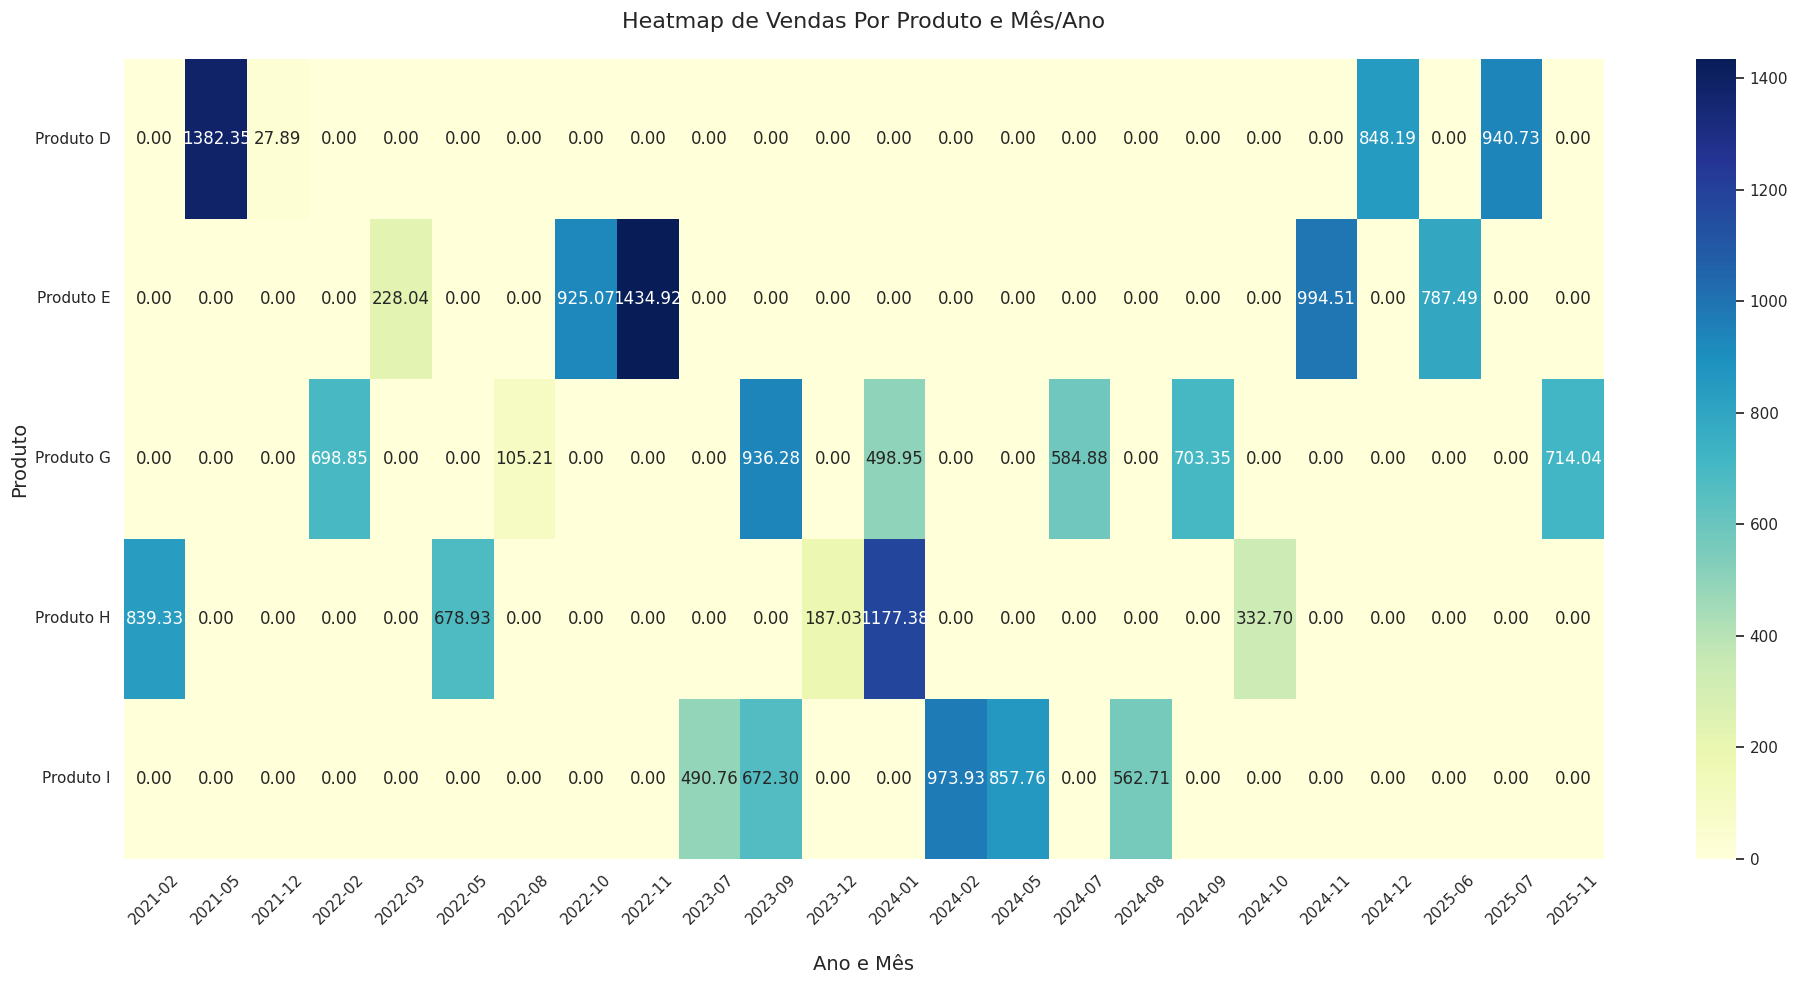

In [28]:
# Heatmap
df_filtered['Ano_Mes'] = df_filtered['Data'].dt.to_period('M').astype(str)
heatmap_data = df_filtered.pivot_table(index = 'Produto',
                                       columns = 'Ano_Mes',
                                       values = 'Total_Vendas',
                                       fill_value = 0)
plt.figure(figsize = (20, 10))
sns.heatmap(heatmap_data, annot = True, fmt = '.2f', cmap = 'YlGnBu')
plt.title('Heatmap de Vendas Por Produto e Mês/Ano\n', fontsize = 16)
plt.xlabel('\nAno e Mês', fontsize = 14)
plt.ylabel('Produto', fontsize = 14)
plt.xticks(rotation = 45)
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()

# Análise de Comportamento do Cliente
Vamos fazer juma análise de frequência de compra para compreender o comportamento do cliente.

In [31]:
# Define a query SQL
query = """
SELECT cl.Nome AS Cliente, COUNT(f.Produto_ID) AS Numero_Compras, AVG(f.Valor) AS Ticket_Medio
FROM `capitulo08dsa-489811.projeto2.fato_venda` f
JOIN `capitulo08dsa-489811.projeto2.dim_cliente` cl ON f.Cliente_ID = cl.Cliente_ID
GROUP BY cl.Nome
ORDER BY Numero_Compras DESC
"""

In [32]:
# Extrai os dados do BigQuery
df_cliente_frequencia = client.query(query).to_dataframe()

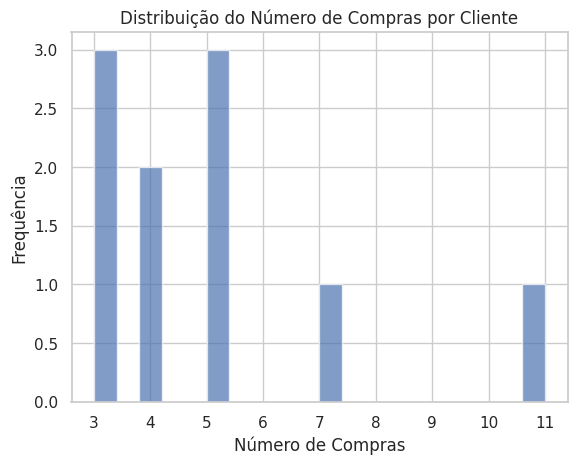

In [33]:
# Exibe distribuição do número de compras por cliente
df_cliente_frequencia['Numero_Compras'].plot(kind = 'hist', bins = 20, alpha = 0.7)
plt.title('Distribuição do Número de Compras por Cliente')
plt.xlabel('Número de Compras')
plt.ylabel('Frequência')
plt.show()

# Análise de Desempenho Regional
Você pode fazer análises por região (cidade, estado, país) para entender o desempenho das vendas em diferentes locais. Isso ajuda a identificar regiões com potencial de crescimento ou áreas onde as vendas estão em declínio.

In [40]:
# Define a query
query = """
SELECT cl.Cidade, cl.Estado, SUM(f.Valor) AS Total_Vendas
FROM `capitulo08dsa-489811.projeto2.fato_venda` f
JOIN `capitulo08dsa-489811.projeto2.dim_cliente` cl ON f.Cliente_ID = cl.Cliente_ID
GROUP BY cl.Cidade, cl.Estado
ORDER BY Total_Vendas DESC
LIMIT 10
"""

In [37]:
# Extrai os dados do BigQuery
df_vendas_regiao = client.query(query).to_dataframe()

<Figure size 1400x600 with 0 Axes>

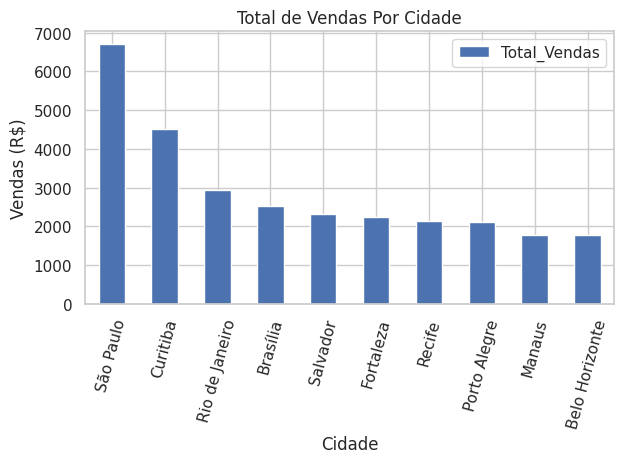

In [38]:
# Define o tamanho da figura
plt.figure(figsize = (14, 6))

# Exibe resultados
df_vendas_regiao.plot(kind = 'bar', x = 'Cidade', y = 'Total_Vendas')
plt.title('Total de Vendas Por Cidade')
plt.ylabel('Vendas (R$)')
plt.xlabel('Cidade')
plt.xticks(rotation = 75)
plt.tight_layout()
plt.show()

In [45]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "Eduardo Lyrio"

Author: Eduardo Lyrio



In [46]:
!pip show google-cloud-bigquery | grep Version

Version: 3.40.1


In [47]:
!pip show db-dtypes | grep Version

Version: 1.5.0


In [48]:
%watermark -v -m

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.6.113+
Machine     : x86_64
Processor   : x86_64
CPU cores   : 2
Architecture: 64bit



In [49]:
%watermark --iversions

google    : 3.0.0
matplotlib: 3.10.0
pandas    : 2.2.2
plotly    : 5.24.1
seaborn   : 0.13.2



# Fim